<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/main/Classifica%C3%A7%C3%A3o_BloodMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# -*- coding: utf-8 -*-
"""
Atividade Prática: Classificação BloodMNIST (8 classes)
Arquitetura: CNN + Algoritmos Genéticos para Otimização
"""

# ==============================================================================
# 1. INSTALAÇÃO E IMPORTAÇÃO DE DEPENDÊNCIAS
# ==============================================================================
# O MedMNIST não vem instalado por padrão no Colab
!pip install medmnist pygad --quiet

import medmnist
from medmnist import INFO
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pygad

print("Bibliotecas carregadas com sucesso!")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.1 MB/s eta 0:00:00
Bibliotecas carregadas com sucesso!


In [3]:
# ==============================================================================
# 2. CARREGAMENTO E CONFIGURAÇÃO DO DATASET BLOODMNIST
# ==============================================================================
data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Carregando os dados
train_dataset = DataClass(split='train', download=True)
test_dataset = DataClass(split='test', download=True)

# Transformando para arrays NumPy e normalizando (0 a 1)
x_train = train_dataset.imgs.astype('float32') / 255.0
y_train = train_dataset.labels.flatten()
x_test = test_dataset.imgs.astype('float32') / 255.0
y_test = test_dataset.labels.flatten()

# Mapeamento das 8 labels
class_names = [
    'Basophil', 'Eosinophil', 'Erythroblast', 'Immature Granulocytes',
    'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet'
]

print(f"Formato dos dados: {x_train.shape}") # Deve mostrar (N, 28, 28, 3)
print(f"Número de classes: {len(class_names)}")


100%|██████████| 35.5M/35.5M [00:02<00:00, 12.9MB/s]


Formato dos dados: (11959, 28, 28, 3)
Número de classes: 8


In [4]:
# ==============================================================================
# 3. CONSTRUÇÃO DA REDE NEURAL CONVOLUCIONAL (CNN)
# ==============================================================================
def build_cnn(num_dense_neurons):
    """
    Cria uma arquitetura de rede neural convolucional.
    O parâmetro num_dense_neurons será otimizado pelo Algoritmo Genético.
    """
    model = models.Sequential([
        # Bloco Convolucional 1: Extração de bordas e texturas
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3)),
        layers.MaxPooling2D((2, 2)), # Redução de dimensionalidade

        # Bloco Convolucional 2: Combinação de padrões complexos
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(), # Converte matrizes 2D para vetor 1D

        # Camada Densa Oculta: Onde o Algoritmo Genético atua
        layers.Dense(int(num_dense_neurons), activation='relu'),
        layers.Dropout(0.2), # Técnica para evitar Overfitting

        # Camada de Saída: 8 neurônios com Softmax para as 8 categorias de células
        layers.Dense(8, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [11]:
# ==============================================================================
# 4. ALGORITMO GENÉTICO PARA HIPERPARAMETRIZAÇÃO
# ==============================================================================
def fitness_function(ga_instance, solution, solution_idx):
    """
    Calcula a 'aptidão' da solução. Quanto maior a acurácia, melhor a solução.
    """

    neurons = solution[0]
    # Criamos o modelo com a sugestão do gene atual
    print(neurons)
    model = build_cnn(neurons)

    # Treino simplificado para avaliação do indivíduo (2 épocas para agilidade)
    # Nota: Em um projeto real, usaríamos uma parcela menor dos dados para velocidade
    history = model.fit(x_train[:3000], y_train[:3000], epochs=2, verbose=0)
    print(history)
    accuracy = history.history['accuracy'][-1]
    return accuracy

# Configuração do PyGAD
ga_instance = pygad.GA(
    num_generations=5,          # Ciclos de evolução
    num_parents_mating=2,       # Melhores pais que cruzam
    fitness_func=fitness_function,
    sol_per_pop=4,              # Indivíduos na população
    num_genes=1,                # Apenas 1 gene: quantidade de neurônios
    gene_type=int,
    init_range_low=64,          # Mínimo de neurônios sugerido
    init_range_high=512         # Máximo de neurônios sugerido
)

print("\n--- Iniciando Processo Evolutivo (Algoritmo Genético) ---")
ga_instance.run()

best_sol, best_fitness, _ = ga_instance.best_solution()
print(f"Evolução concluída! Melhor número de neurônios encontrado: {best_sol[0]}")



/usr/local/lib/python3.12/dist-packages/pygad/utils/validation.py:670: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Iniciando Processo Evolutivo (Algoritmo Genético) ---
352
240
212
169
168
351
168
350
350
350
350
350
350
Evolução concluída! Melhor número de neurônios encontrado: 351


In [6]:
# ==============================================================================
# 5. TREINAMENTO FINAL E CROSS-VALIDATION
# ==============================================================================
final_neurons = int(best_sol[0])
print(f"\nTreinando modelo final com {final_neurons} neurônios...")

# Criamos o modelo otimizado
final_model = build_cnn(final_neurons)

# Treinamento completo
history = final_model.fit(x_train, y_train,
                          epochs=10,
                          batch_size=32,
                          validation_split=0.2) # Cross-validation interna


Treinando modelo final com 395 neurônios...
Epoch 1/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6413 - loss: 0.9732 - val_accuracy: 0.7780 - val_loss: 0.6234
Epoch 2/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7900 - loss: 0.5831 - val_accuracy: 0.8395 - val_loss: 0.5018
Epoch 3/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.8227 - loss: 0.4997 - val_accuracy: 0.8332 - val_loss: 0.4552
Epoch 4/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8523 - loss: 0.4151 - val_accuracy: 0.8662 - val_loss: 0.3797
Epoch 5/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8611 - loss: 0.3902 - val_accuracy: 0.8846 - val_loss: 0.3441
Epoch 6/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8742 - loss: 0.3500 - val_accuracy: 0.8976 - val_loss: 0.2999
Epoch 7/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8816 - loss: 0.3243 - val_accuracy: 0.8717 - val_loss: 0.3539
Epoch 8/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 20s 4

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


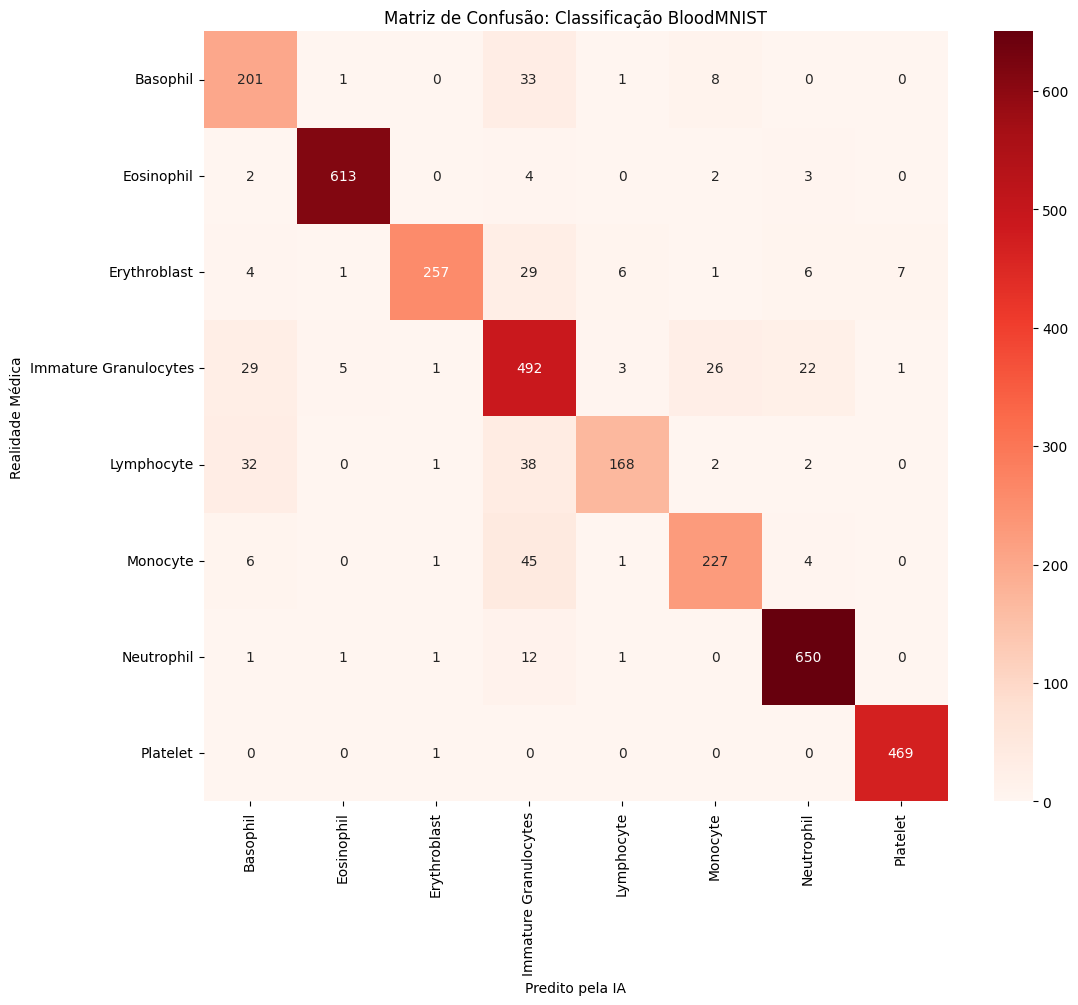


--- Relatório de Performance Acadêmica ---
                       precision    recall  f1-score   support

             Basophil       0.73      0.82      0.77       244
           Eosinophil       0.99      0.98      0.98       624
         Erythroblast       0.98      0.83      0.90       311
Immature Granulocytes       0.75      0.85      0.80       579
           Lymphocyte       0.93      0.69      0.79       243
             Monocyte       0.85      0.80      0.83       284
           Neutrophil       0.95      0.98      0.96       666
             Platelet       0.98      1.00      0.99       470

             accuracy                           0.90      3421
            macro avg       0.90      0.87      0.88      3421
         weighted avg       0.91      0.90      0.90      3421



In [7]:
# ==============================================================================
# 6. AVALIAÇÃO: MATRIZ DE CONFUSÃO E RELATÓRIO
# ==============================================================================
# Realizar predições no set de teste
predictions = final_model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)

# Gerar Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão: Classificação BloodMNIST')
plt.xlabel('Predito pela IA')
plt.ylabel('Realidade Médica')
plt.show()

print("\n--- Relatório de Performance Acadêmica ---")
print(classification_report(y_test, y_pred, target_names=class_names))

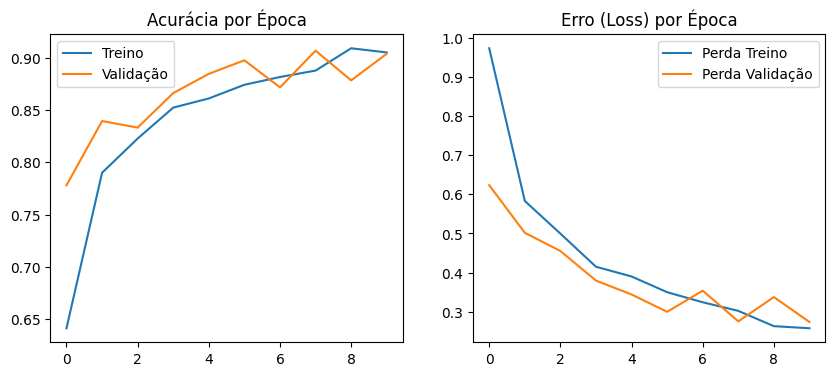


Processo finalizado. O modelo está pronto para demonstração.


In [8]:
# ==============================================================================
# 7. VISUALIZAÇÃO DE RESULTADOS DO TREINO
# ==============================================================================
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda Treino')
plt.plot(history.history['val_loss'], label='Perda Validação')
plt.title('Erro (Loss) por Época')
plt.legend()
plt.show()

print("\nProcesso finalizado.")